[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/rycroft-group/math513/blob/main/6_iter/6_iter.ipynb)

In [1]:
# Necessity libraries
import numpy as np
import matplotlib.pyplot as plt

# Optional: a library for plotting with LaTeX-like
# styles nicer formatted figures
# Warning: need to have LaTeX installed
import scienceplots
plt.style.use(['science'])

In [2]:
import os
os.makedirs("results", exist_ok=True)

# Unit 6: Iterative methods

## Lecture 34: More on Arnoldi iteration

### Code demo 1: Use Arnoldi iteration to approximate eigenvalues of a matrix

Ritz values:
[2.99985015 2.071445   1.46330969 0.2884798  0.62256401 0.96849916]


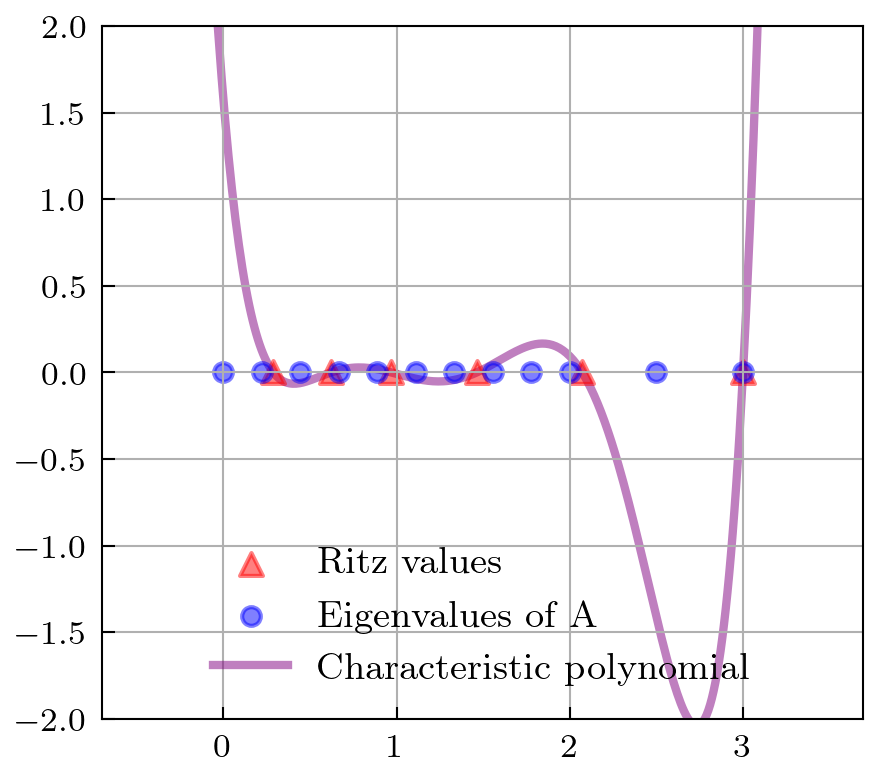

In [3]:
# Define the vector A
w = 10
diag_vector = np.concatenate([np.linspace(0, 2, w), [2.5, 3.0]])
A = np.diag(diag_vector)
m = w + 2

# Initialize Q, alpha, and beta
n_max = 6
Q = np.zeros((m, n_max))

# Define a random initial vector
b = np.random.randn(m)
Q[:, 0] = b / np.linalg.norm(b)

# The Arnoldi iteration loop
for n in range(n_max - 1):
    v = A @ Q[:, n]
    for l in range(n + 1):
        s = np.dot(Q[:, l].conj(), v)
        v = v - s * Q[:, l]
    b = np.linalg.norm(v)
    Q[:, n + 1] = v / b

H_n = Q.T @ A @ Q
V = np.linalg.eigvals(H_n)

fig, ax = plt.subplots(1, 1, figsize=(4, 3), dpi=300)
# Plot the roots
ax.scatter(V, np.zeros_like(V), s=30, marker='^', color='r', label='Ritz values', alpha=0.5)
ax.scatter(diag_vector, np.zeros_like(diag_vector), s=20, color='blue', label='Eigenvalues of A', alpha=0.5)
# Plot the characteristic polynomial
p = np.poly(H_n)
xrange = np.arange(-0.5, 3.5, 0.01)
ax.plot(xrange, np.polyval(p, xrange), color='purple', linewidth=2, label='Characteristic polynomial', zorder=0, alpha=0.5)

# Formatting
ax.set_ylim(-2, 2)
ax.legend(loc='lower center', fontsize=9)
# Prettify
ax.grid(True, linewidth=0.5)
ax.set_aspect('equal')
# ax.set_xlim(-0.5, 3.5)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.tick_params(axis='both', which='minor', bottom=False, left=False)
ax.tick_params(axis='both', which='both', right=False, top=False)

# Print out the Ritz values
print("Ritz values:")
print(V)